In [568]:
import seaborn as sns
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import sklearn.linear_model as lm
from scipy.optimize import minimize
import plotly.express as px
import plotly.graph_objs as go
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
'Imports Complete'

'Imports Complete'

$Part$ 1$: Data$

For this project, I am using a dataset from the 'U.S. Department of Health & Human Services: Centers for Disease Control and Prevention' located on data.gov, which is 'Nutrition, Physical Activity, and Obesity - Behavioral Risk Factor Surveillance System'. 
This is the link to the website and dataset: https://catalog.data.gov/dataset/nutrition-physical-activity-and-obesity-behavioral-risk-factor-surveillance-system . With this dataset, it covers years 2011-2023 (13 years of total data) and includes state level and demographic information. With this, I am wanting to explore the trend over time in Oregon, and want to explore: 

How has nutrition changed over time in Oregon, and how do these trends differ by sex, income and occupation? Are there any linear trends among the groups? The goal is to identify and find if there are certain groups or classes in Oregon that are experiencing better or worse nutrition over time, and use this data to better understand the behavior and pattern. 

In [569]:
nutrition = pd.read_csv('Nutrition_Physical_Activity_and_Obesity_Behavioral_Risk_Factor_Surveillance_System.csv')

nutrition

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106255,2023,2023,VI,Virgin Islands,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(18.335765, -64.896335)",PA,PA1,Q047,VALUE,78,Race/Ethnicity,Non-Hispanic Black,RACE,RACEBLK
106256,2023,2023,VI,Virgin Islands,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(18.335765, -64.896335)",PA,PA1,Q047,VALUE,78,Race/Ethnicity,Non-Hispanic White,RACE,RACEWHT
106257,2023,2023,VI,Virgin Islands,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(18.335765, -64.896335)",PA,PA1,Q047,VALUE,78,Race/Ethnicity,Other,RACE,RACEOTH
106258,2023,2023,VI,Virgin Islands,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(18.335765, -64.896335)",PA,PA1,Q047,VALUE,78,Education,Some college or technical school,EDU,EDUCOTEC


$Part$ 2$: Exploration$

now that I have ran the data, I want to first see if there are any missing values, any issues in our data, or anything that would offset or skew our results.

From what we know so far, we can see that our data is 106,260 x 33 rows. Let's check to see what each column represents.

In [570]:
nutrition.info()  # we can see that we have a variety of types (int, object aka string, float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106260 entries, 0 to 106259
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   106260 non-null  int64  
 1   YearEnd                     106260 non-null  int64  
 2   LocationAbbr                106260 non-null  object 
 3   LocationDesc                106260 non-null  object 
 4   Datasource                  106260 non-null  object 
 5   Class                       106260 non-null  object 
 6   Topic                       106260 non-null  object 
 7   Question                    106260 non-null  object 
 8   Data_Value_Unit             0 non-null       float64
 9   Data_Value_Type             106260 non-null  object 
 10  Data_Value                  93505 non-null   float64
 11  Data_Value_Alt              93505 non-null   float64
 12  Data_Value_Footnote_Symbol  12755 non-null   object 
 13  Data_Value_Foo

Now let's check to see if we have any missing values.

In [571]:
nutrition.isna().sum()

YearStart                          0
YearEnd                            0
LocationAbbr                       0
LocationDesc                       0
Datasource                         0
Class                              0
Topic                              0
Question                           0
Data_Value_Unit               106260
Data_Value_Type                    0
Data_Value                     12755
Data_Value_Alt                 12755
Data_Value_Footnote_Symbol     93505
Data_Value_Footnote            93505
Low_Confidence_Limit           12755
High_Confidence_Limit          12755
Sample_Size                    12755
Total                         102465
Age(years)                     83490
Education                      91080
Sex                            98670
Income                         79695
Race/Ethnicity                 75900
GeoLocation                     1932
ClassID                            0
TopicID                            0
QuestionID                         0
D

By checking to see if the values are na, and then taking the sum of those na's, we can see that we have a few columns that have na's. The column 'Data_Value_Unit' is missing entirely, and 'Total' doesn't have much information either. We also have a few other columns that are nearing those quantities, which mean they either wouldn't be much use to us, or they would be an issue to finding specific questions. 

Since we don't to just fill in the na values (because they are missing for a reason), we will first filter by only taking the columns that are important to us. Then we will also make it easier to read by renaming some columns. 

In [572]:
nutrition['Class'].value_counts(), nutrition['Topic'].value_counts()
# with this code, we can see that they are basically the same, so we will keep class
nutrition['Datasource'].value_counts() # dont need either 

# StratificationId1 is just short for StratificationCategory1

Datasource
Behavioral Risk Factor Surveillance System    106260
Name: count, dtype: int64

After looking into the data, as well as the source, I was able to find that the column 'Data_Value' represents the percentage associated with whatever question is being asked. For example, if a question is looking as the percent of adults aged 18 years and older who have obesity at a specific location / demographic / stratification, etc, the percentage will tell us how many people have that. 

In [573]:
filtered = nutrition[['YearStart', 'LocationAbbr', 'LocationDesc', 'Class',
                      'Question','Data_Value', 'Age(years)', 'Sex', 'Income', 'Race/Ethnicity',
                      'StratificationCategory1', 'Stratification1']]

filtered = filtered.rename(columns = {'YearStart': 'Year', 'LocationAbbr': 'StateAbbr', 'LocationDesc': 'State', 
                                      'Datasource': 'Category'})

filtered

,Year,StateAbbr,State,Class,Question,Data_Value,Age(years),Sex,Income,Race/Ethnicity,StratificationCategory1,Stratification1
0,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.8,NaN,NaN,"$15,000 - $24,999",NaN,Income,"$15,000 - $24,999"
1,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,35.8,NaN,NaN,"$25,000 - $34,999",NaN,Income,"$25,000 - $34,999"
2,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,32.3,NaN,NaN,"$35,000 - $49,999",NaN,Income,"$35,000 - $49,999"
3,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.1,NaN,NaN,"$50,000 - $74,999",NaN,Income,"$50,000 - $74,999"
4,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,28.8,NaN,NaN,"$75,000 or greater",NaN,Income,"$75,000 or greater"
...,...,...,...,...,...,...,...,...,...,...,...,...
106255,2023,VI,Virgin Islands,Physical Activity,Percent of adults who engage in no leisure-tim...,33.2,NaN,NaN,NaN,Non-Hispanic Black,Race/Ethnicity,Non-Hispanic Black
106256,2023,VI,Virgin Islands,Physical Activity,Percent of adults who engage in no leisure-tim...,20.5,NaN,NaN,NaN,Non-Hispanic White,Race/Ethnicity,Non-Hispanic White
106257,2023,VI,Virgin Islands,Physical Activity,Percent of adults who engage in no leisure-tim...,23.7,NaN,NaN,NaN,Other,Race/Ethnicity,Other
106258,2023,VI,Virgin Islands,Physical Activity,Percent of adults who engage in no leisure-tim...,28.1,NaN,NaN,NaN,NaN,Education,Some college or technical school


Now that we have filtered out the columns that we want, we want to just look at Oregon. We can do this by filtering to only find data that is in Oregon. We will make a new data table for this.  

In [574]:
oregon = filtered[filtered['StateAbbr'] == 'OR']
oregon

,Year,StateAbbr,State,Class,Question,Data_Value,Age(years),Sex,Income,Race/Ethnicity,StratificationCategory1,Stratification1
1036,2011,OR,Oregon,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,29.6,NaN,NaN,"$15,000 - $24,999",NaN,Income,"$15,000 - $24,999"
1037,2011,OR,Oregon,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,29.8,NaN,NaN,"$25,000 - $34,999",NaN,Income,"$25,000 - $34,999"
1038,2011,OR,Oregon,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,28.9,NaN,NaN,"$35,000 - $49,999",NaN,Income,"$35,000 - $49,999"
1039,2011,OR,Oregon,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,24.4,NaN,NaN,"$50,000 - $74,999",NaN,Income,"$50,000 - $74,999"
1040,2011,OR,Oregon,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,22.9,NaN,NaN,"$75,000 or greater",NaN,Income,"$75,000 or greater"
...,...,...,...,...,...,...,...,...,...,...,...,...
105779,2023,OR,Oregon,Physical Activity,Percent of adults who engage in no leisure-tim...,21.2,NaN,NaN,NaN,Non-Hispanic Black,Race/Ethnicity,Non-Hispanic Black
105780,2023,OR,Oregon,Physical Activity,Percent of adults who engage in no leisure-tim...,18.9,NaN,NaN,NaN,Non-Hispanic White,Race/Ethnicity,Non-Hispanic White
105781,2023,OR,Oregon,Physical Activity,Percent of adults who engage in no leisure-tim...,16.8,NaN,NaN,NaN,Other,Race/Ethnicity,Other
105782,2023,OR,Oregon,Physical Activity,Percent of adults who engage in no leisure-tim...,21.1,NaN,NaN,NaN,NaN,Education,Some college or technical school


Lets look at how many different values we have for each category.

In [575]:
oregon['StratificationCategory1'].value_counts(), oregon['Stratification1'].value_counts()

(StratificationCategory1
 Race/Ethnicity    552
 Income            483
 Age (years)       414
 Education         276
 Sex               138
 Total              69
 Name: count, dtype: int64,
 Stratification1
 $15,000 - $24,999                   69
 $25,000 - $34,999                   69
 Some college or technical school    69
 Other                               69
 Non-Hispanic White                  69
 Non-Hispanic Black                  69
 Male                                69
 Less than high school               69
 Less than $15,000                   69
 Hispanic                            69
 High school graduate                69
 Hawaiian/Pacific Islander           69
 Female                              69
 Data not reported                   69
 College graduate                    69
 Asian                               69
 American Indian/Alaska Native       69
 65 or older                         69
 55 - 64                             69
 45 - 54                        

In [576]:
oregon['Question'].unique()  # this will give us what is being studied

array(['Percent of adults aged 18 years and older who have obesity',
       'Percent of adults aged 18 years and older who have an overweight classification',
       'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)',
       'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week',
       'Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)',
       'Percent of adults who engage in muscle-strengthening activities on 2 or more days a week',
       'Percent of adults who engage in

Lets look at a few associations, and different relationships with the information that we have. 

Text(0.5, 1.0, 'Distribution of obesity related percentages in Oregon')

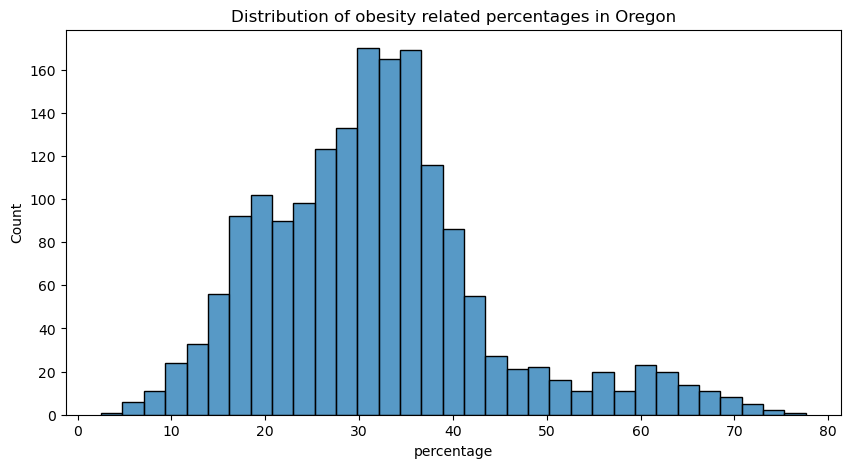

In [577]:
plt.figure(figsize=(10, 5))
sns.histplot(oregon['Data_Value'])
plt.xlabel('percentage')
plt.title('Distribution of obesity related percentages in Oregon')


This is the distribution of obesity percentages in Oregon, and we can see that it is pretty scattered, but there lies a lot between 20-40 percent. This considers all questions, nothing specific to look at. With that being said, it is misleading on what we are actually looking at here.

Now, we want to specifically look at adults in Oregon (people over 18). 

Text(0.5, 1.0, 'Obesity percentage in Oregon for adults 18 and older over time')

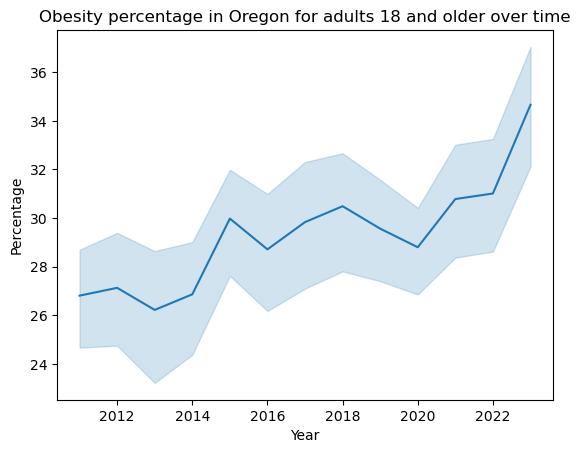

In [578]:
# oregon_by_year = oregon.groupby('Year')
# oregon_by_year.head()

above_18_obese = oregon[oregon['Question'] == 'Percent of adults aged 18 years and older who have obesity']
sns.lineplot(data = above_18_obese, x = 'Year', y = 'Data_Value')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title('Obesity percentage in Oregon for adults 18 and older over time')

The graph above shows us the the percentage / rate of obesity over time for adults in Oregon. This doesn't account for any specific measures like income, race, sex, etc, but more so all the population studied as a whole. We can see that the average percentage is slowly growing over time, which means that there is a factor that we have yet to discover that is affecting these results. Let's take a deeper dive into what could be causing this, or if there is a trend with our other values. 

Before we jump into that though, let's take a quick look at the difference between obesity in 2011 to 2023.

In [579]:
first = above_18_obese[above_18_obese['Year'] == 2011]['Data_Value'].iloc[0]
last = above_18_obese[above_18_obese['Year'] == 2023]['Data_Value'].iloc[0]
change_over_time = last - first
change_over_time
# This is the change in obesity over time, and we can see that it has roughly gone up by 9%. Let's take a look at other trends
# and associations

9.799999999999997

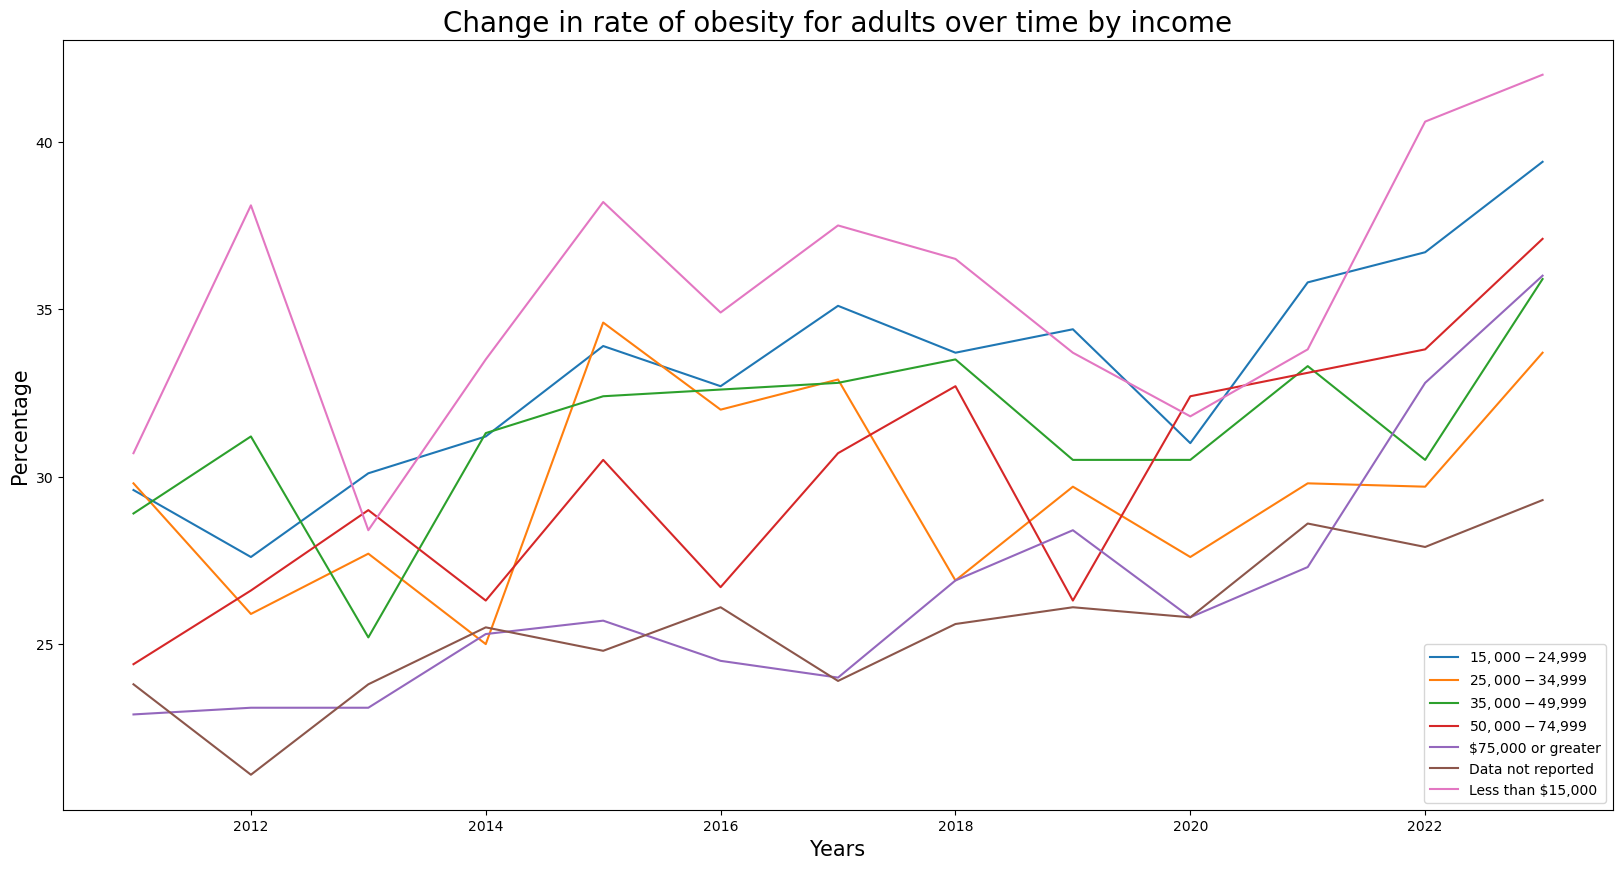

In [580]:
plt.figure(figsize = (20, 10))

sns.lineplot(data = above_18_obese, x = 'Year', y = 'Data_Value', hue = 'Income')

plt.xlabel('Years', fontsize = 15)
plt.ylabel('Percentage', fontsize = 15)
plt.title('Change in rate of obesity for adults over time by income', fontsize = 20)
plt.legend(loc = 'lower right')

After taking a look at each line, we can see that the lower income class has a higher rate over time of having obesity. This could be for many reasons, from the lower class not being able to afford healthier and fresher foods, to being limited on the healthcare they are able to afford, as well as education, physical activity resources, etc. With this, we can also take a look at race to see if there is a trend there.

Text(0.5, 1.0, 'Change in rate of obesity for adults over time by race')

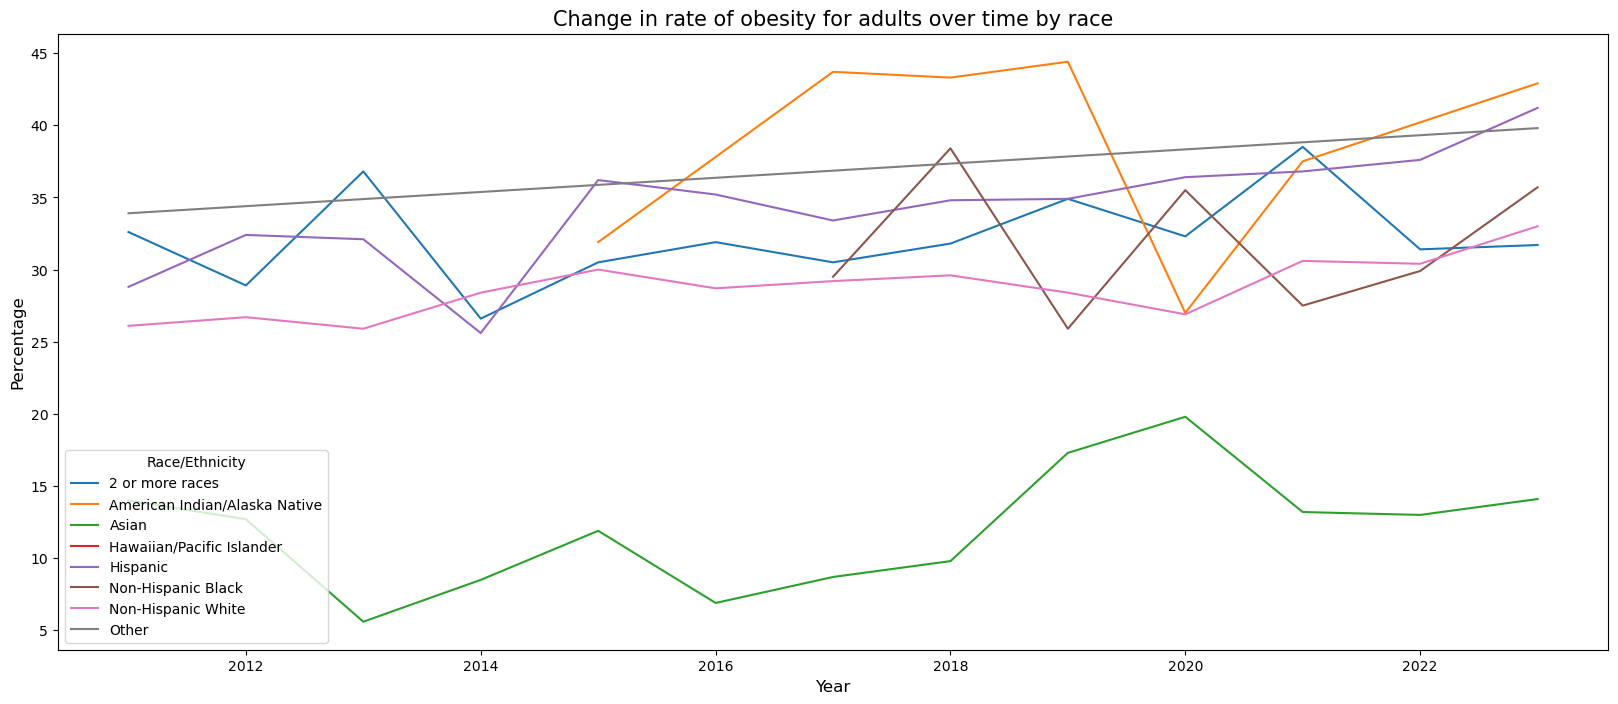

In [581]:
plt.figure(figsize = (20, 8))

sns.lineplot(data = above_18_obese, x = 'Year', y = 'Data_Value', hue = 'Race/Ethnicity')

plt.xlabel('Year', fontsize = 12)
plt.ylabel('Percentage', fontsize = 12)
plt.title('Change in rate of obesity for adults over time by race', fontsize = 15)

This plot doesn't say too much. We can see that for all different ethnic/race groups, they have each had a pretty consistant trend along the years (consistency from where they started at), with some dipping and high points. One thing we do see though, is that the Asian group has significantly lower percentage of obesity in adults compared to the rest that were studied. Since this dataset only dates back to 2011, this could mean that these patterns were developed prior to the study, which could be connected to cultural backgrounds and traditions, as well as socioeconomic factors that change between ethnic groups. Since our study only provides a percentage of the data that was studied, and not all studies had information on their race, this means that we would need to look deeper to find more evidence and connections before concluding to anything. 

We can also take a look at all the different questions that were studied on and see the trends in those. We will compare those to income as well and see if or how they differ from one another.

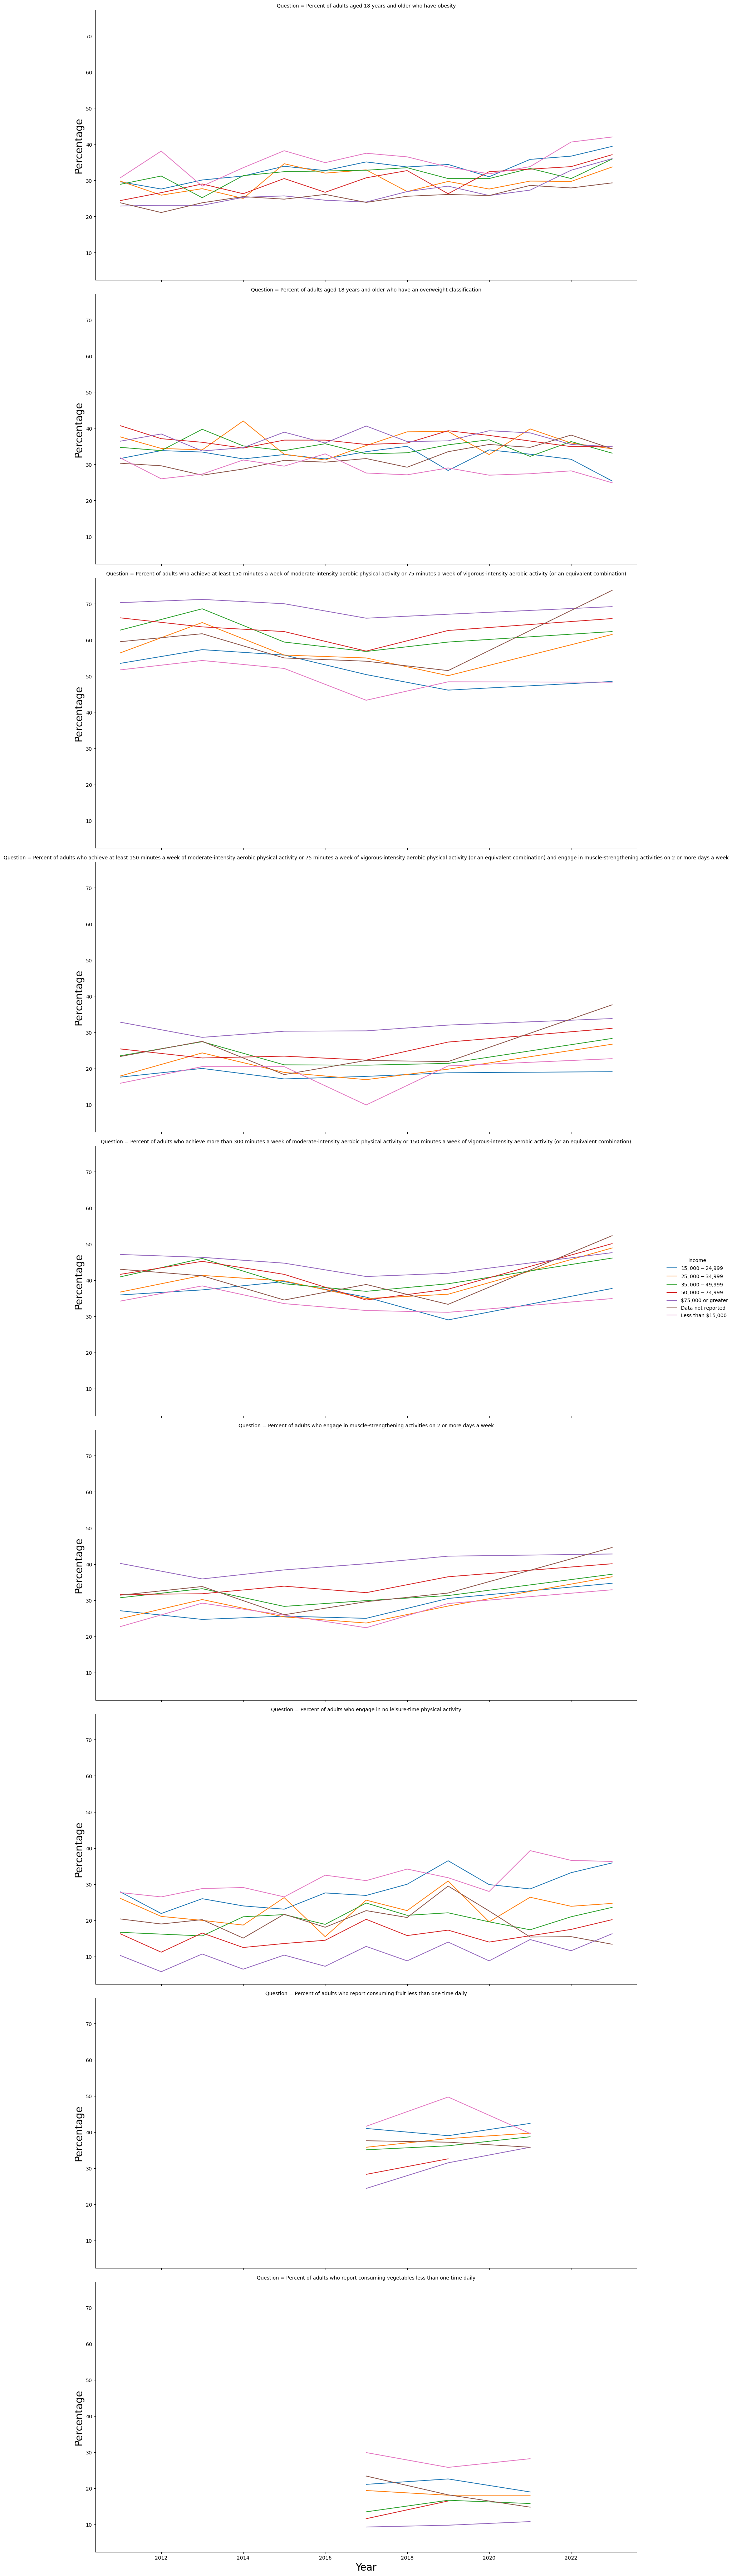

In [582]:
questions = oregon['Question'].unique() #looking again at the different questions 
# questions

sns.relplot(data = oregon, x = 'Year', y = 'Data_Value', hue = 'Income', kind = 'line',
            
           col = 'Question', col_wrap = 1, height = 8, aspect = 2).set_axis_labels('Year', 'Percentage', fontsize = 20)
#plt.x & y labels would not work in this case, would only replace the bottom one


This is just a quick snapshot of the relationship between the questions and income throughout the years. Now that we have seen this data, we can see that some questions don't have enough evidence or data to support its claim, or to give us a conclusion of the trend or relationship. To end this section off, let's just see what we are working with and the amount of info we have for Oregon.

In [583]:
oregon.describe(), oregon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1932 entries, 1036 to 105783
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     1932 non-null   int64  
 1   StateAbbr                1932 non-null   object 
 2   State                    1932 non-null   object 
 3   Class                    1932 non-null   object 
 4   Question                 1932 non-null   object 
 5   Data_Value               1742 non-null   float64
 6   Age(years)               414 non-null    object 
 7   Sex                      138 non-null    object 
 8   Income                   483 non-null    object 
 9   Race/Ethnicity           552 non-null    object 
 10  StratificationCategory1  1932 non-null   object 
 11  Stratification1          1932 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 196.2+ KB


(              Year   Data_Value
 count  1932.000000  1742.000000
 mean   2016.942029    31.813892
 std       3.749919    12.280887
 min    2011.000000     2.500000
 25%    2014.000000    23.500000
 50%    2017.000000    31.200000
 75%    2020.000000    37.200000
 max    2023.000000    77.600000,
 None)

We can see that with the 1932 total rows that we are working with, there are many missing values for Race/Ethnicity, Age(years), and sex which may affect our representation of relationships. This helps explain why some of our graphs above seem like that aren't representing right or giving us a full picture. From our data value, we can see that our range is from 2.5 - 77.6, with our mean being around 31.8.

By the information that we do have though, we have a lot of data showing us the trend of percentage of obesity throughout the years, as we have enough data value to support it, but we do lack on some other demographic fields which may be hard to interpret. 

In summary, we are able to still use our data to understand how obesity has changed over time in Oregon, and we have different demographic and related statistics to evaluate trends and key changes throughout the years. Since we also have a lot of missing values, we do however, have to be extra cautious when evaluating these behaviors and trends over time. 

$Part$ 3$: Inference$

For part 3, we want to use our data and what we know about it to learn something about the world. From what we have done so far, we have been looking at trends in Oregon specifically. Our dataset covers every state, and we haven't used most of the data. With that, I want to learn the trend of obesisty over time and compare it to income. While we do that, I want to look and see if certain parts in the US (states), like the west or east coast, have a different approach or significance of trend to this, and learn why that could possibly be.

With this, my main question is: Does income level predict obesity percentage in the US, and do different ethnic/race groups show a higher or lower trend compared to each other? From that, I will be conducting this hypothesis:

Null hypothesis: There is no relationship between income groups and obesity percentage in adults.

Alternative hypothesis: Higher income groups have lower obesity percentage across the US in adults.

$Hypothesis:$

In [584]:
# lets go back to filtered, where we filter the columns that we need, while still keeping all states
filtered.head()

,Year,StateAbbr,State,Class,Question,Data_Value,Age(years),Sex,Income,Race/Ethnicity,StratificationCategory1,Stratification1
0,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.8,NaN,NaN,"$15,000 - $24,999",NaN,Income,"$15,000 - $24,999"
1,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,35.8,NaN,NaN,"$25,000 - $34,999",NaN,Income,"$25,000 - $34,999"
2,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,32.3,NaN,NaN,"$35,000 - $49,999",NaN,Income,"$35,000 - $49,999"
3,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.1,NaN,NaN,"$50,000 - $74,999",NaN,Income,"$50,000 - $74,999"
4,2011,AL,Alabama,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,28.8,NaN,NaN,"$75,000 or greater",NaN,Income,"$75,000 or greater"


In [585]:
# now lets filter by the question, so we know what we are looking at exactly
# filtered['Question'].unique()
obesity = filtered[filtered['Question'] == 'Percent of adults aged 18 years and older who have obesity']
# obesity

In [586]:
# now lets filter to the columns that we will only need
obesity_income = obesity[obesity['StratificationCategory1'] == 'Income']
obesity_income = obesity_income[['Year', 'State', 'Data_Value', 'Stratification1']]
obesity_income.rename(columns = {'Stratification1': 'Income'}, inplace = True)
obesity_income = obesity_income[obesity_income['Income'] != 'Data not reported']
obesity_income

,Year,State,Data_Value,Income
0,2011,Alabama,34.8,"$15,000 - $24,999"
1,2011,Alabama,35.8,"$25,000 - $34,999"
2,2011,Alabama,32.3,"$35,000 - $49,999"
3,2011,Alabama,34.1,"$50,000 - $74,999"
4,2011,Alabama,28.8,"$75,000 or greater"
...,...,...,...,...
96993,2023,Virgin Islands,31.2,"$25,000 - $34,999"
96994,2023,Virgin Islands,38.7,"$35,000 - $49,999"
96995,2023,Virgin Islands,32.8,"$50,000 - $74,999"
96996,2023,Virgin Islands,33.1,"$75,000 or greater"


In [587]:
# obesity_income['Stratification1'].unique()
# Less than 15,000
# 15,000 - 24,999
# 25,000 - 34,999
# 35,000 - 49,999
# 50,000 - 74,999
# 75,000 or greater
# Data not reported

In [588]:
# since our income column is a tring type, lets add a column that has int for each income catagory
# obesity_income['Income'].unique()

obesity_income['Category'] = obesity_income['Income'].replace('$15,000 - $24,999', 1).replace(
    '$25,000 - $34,999', 2).replace('$35,000 - $49,999', 3).replace('$50,000 - $74,999', 4).replace(
    '$75,000 or greater', 5).replace('Less than $15,000', 0)

obesity_income

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_71703/4056420127.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  '$75,000 or greater', 5).replace('Less than $15,000', 0)


,Year,State,Data_Value,Income,Category
0,2011,Alabama,34.8,"$15,000 - $24,999",1
1,2011,Alabama,35.8,"$25,000 - $34,999",2
2,2011,Alabama,32.3,"$35,000 - $49,999",3
3,2011,Alabama,34.1,"$50,000 - $74,999",4
4,2011,Alabama,28.8,"$75,000 or greater",5
...,...,...,...,...,...
96993,2023,Virgin Islands,31.2,"$25,000 - $34,999",2
96994,2023,Virgin Islands,38.7,"$35,000 - $49,999",3
96995,2023,Virgin Islands,32.8,"$50,000 - $74,999",4
96996,2023,Virgin Islands,33.1,"$75,000 or greater",5


Text(0.5, 1.0, 'Average obesity percentage in the U.S. compared to income (5 = highest) for adults over 18')

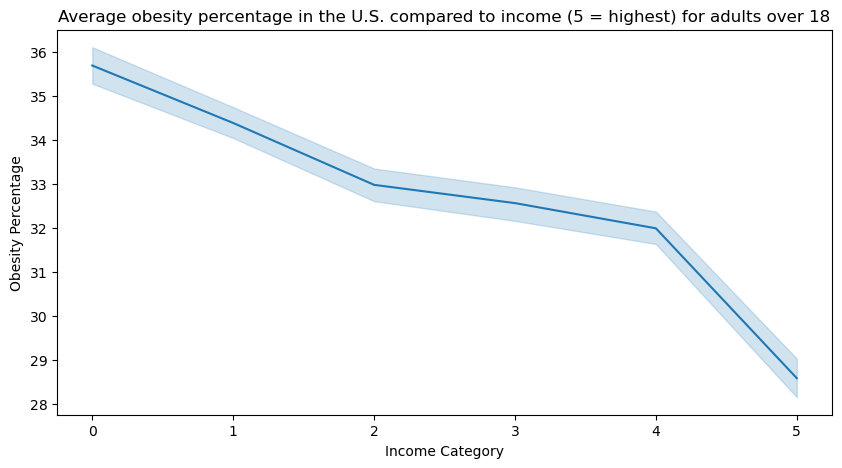

In [589]:
plt.figure(figsize = (10, 5))

sns.lineplot(data = obesity_income, x = 'Category', y = 'Data_Value')
plt.xlabel('Income Category')
plt.ylabel('Obesity Percentage')
plt.title('Average obesity percentage in the U.S. compared to income (5 = highest) for adults over 18')

We can see, comparing the income category to the obesity percentage, that as income becomes higher, the obesity percentage gets lower and lower. This shows a very linear trend (negative). 

In [590]:
model = lm.LinearRegression()

# cleaning up any NA's due to running this prior, i got an error for possible missing values
obesity_income = obesity_income.dropna()

X = obesity_income[['Category']] 
y = obesity_income[['Data_Value']]

model.fit(X, y)

coef = model.coef_
intercept = model.intercept_
coef, intercept

(array([[-1.2319678]]), array([35.7763443]))

With a negative slope, this tells us that for every increase in income category, we see roughly a 1.23 decrease on obesity percentage.

In [591]:
corr = np.corrcoef(obesity_income['Category'], obesity_income['Data_Value'])
corr

# our correlation tells us that we have a strong negative linear relationship, helping prove our hypothesis. 

array([[ 1.       , -0.3779155],
       [-0.3779155,  1.       ]])

After looking at the data, a question that gets brought up is if there is any bias in the data. Are we looking at an accurate model that reflects the relationship between income and obesity percentage? I would say yes. Not due to just our graph showing, but moreso that this dataset took over 10 years to create, and studied every state and captured over 100 thousand samples throughout the country. Outside of what we see with our eye, we have to also consider politics and the economic structure that is in place right now. Healthier and more nutrient loaded foods tend to be pricier, and a lot of healthier option grocery stores require a membership. With this, most low income and lower income individuals don't have access to this, and have to settle from cheaper less healthy food, leading to higher risk in becoming obese and not getting enough nutrients that our body needs. Our income categories were pretty broad, with a decent range in between each category, yet our relationship seems very strong. This proves our alternative hypothesis to be right.

We want to look at one more thing though, let's perform a bootstrap to make sure our intervals prove our statement as well. Bootstrapping will repeatedly resample out dataset and refit the model to create a confidence interval.

In [592]:
def fit_model(df):
    x = df[['Category']].values
    y = df['Data_Value'].values
    model = LinearRegression().fit(x, y)
    return model.coef_[0]

def bootstrap(df): # similar code used from my dsci 345m class, where we saw a simplified bootstrapping method 
    n = df.shape[0]
    return df.loc[rng.choice(df.index, n)]

boots = pd.Series([
    fit_model(bootstrap(obesity_income))
    for i in range(1000)
])
# boots
boots.quantile([0.025, 0.975])

0.025   -1.323306
0.975   -1.138858
dtype: float64

Here, we just competed a 95% confidence interval for our slope. Since both our values are negative, this supports the statement that as income levels increase, obesity decreases. To read our results, it basically says that we are 95% certain that for each level we move on income levels, we would expect to see between a 1.13-1.32 decrease in obesity percentage levels. What we did above is basically create 1000 different datasets sampled from the original, computed the slope for each one, and estimed a 95% confidence interval for income-obesity. 

$Part 4: Prediction$

In this part, we are going to model our data to predict unobserved values of one or more variables of interest. We basically want to create the highest fidelity model possible, aka, the least wrong model. We will use different models for this. 

We will do a train test split first, as we have done in lecture, for our first model. We are going to estimate obesity percentage using income and other variables later on. Our goal is to find what model will give us the 'least wrong' results. We will also compare each model to see their accuracy and which ones would work better. 

In [629]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
# len(obesity_income)

x_vars = ['Category']

# the goal is to predict obesity (data_value) based on category
# Category is going to be our predictor

# we are using a 75/25 split, similarily to lecture
X_train, X_holdout, Y_train, Y_holdout = train_test_split(obesity_income[x_vars], obesity_income['Data_Value'], test_size = 0.25)
len(X_train)

3135

In [630]:
#similarily to lecture, we do a 5 fold
# Each fold contrains 4/5 (75%) of the training data and validates the other 1/5 (25%)

kf = KFold(n_splits = 5)

for train_idx, valid_idx in kf.split(X_train):
    split_X_valid = X_train.iloc[valid_idx,:]

    print(split_X_valid.head())

       Category
91843         4
49395         4
42888         0
42356         0
87055         4
       Category
60594         3
32287         4
41863         4
42900         5
31222         3
       Category
61284         0
79512         0
26883         4
11164         0
15486         3
       Category
91197         2
86467         4
96368         0
42340         5
26376         1
       Category
60200         1
16596         0
67984         1
116           5
11875         4


This basically returns two sets of indices (similar to lecture). We are going to fit the model now on thr training split of the data for each fold. This will predict our values on the validation split and calculate our error.

In [631]:
kf = KFold(n_splits = 5)
validation_errors = np.empty(0)

for train_idx, valid_idx in kf.split(X_train):
    
    split_X_train, split_X_valid = X_train.iloc[train_idx,:], X_train.iloc[valid_idx,:]
    split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx] 
    
    model.fit(split_X_train, split_Y_train)
    
    Y_pred = model.predict(split_X_valid)
    
    validation_errors = np.append(validation_errors, mean_squared_error(split_Y_valid, Y_pred))

validation_errors, np.mean(validation_errors)

# average is around 26, meaning that income does not give the most accurate prediction.
# we will test more models to see if we can improve this. 

(array([30.31359491, 27.61259663, 24.57844973, 24.84021378, 30.09640792]),
 27.488252592801093)

After running this code, we can see that our average error is around 27ish. This means that it is not extremely accurate, so let's move on to our next model to see if we can minimize our error. 

lets try doing a linear regression model to see how low we can get our error to be. Remember that the lower our error / mean squared error, the more accurate our model is.

AKA: we will use mean squared error as our evalutation metric. The lower the MSE, the better our results (accuracy).

In [633]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# lower MSE = higher the accuracy 

l = LinearRegression()
l.fit(X_train, Y_train)
lpred = l.predict(X_holdout)

mean = mean_squared_error(Y_holdout, lpred)
mean

24.076934336020585

after running this model, we see that our MSE did improve by a decent margin, but we want to get it lower. This also suggests that maybe using category itself may not contain enough information to make accurate predictions. Regardless, let's try to use it a little more to see if we can get another model to be more accurate.

In [634]:
from sklearn.ensemble import RandomForestClassifier
# Unknown label type: continuous. Maybe you are trying to fit a classifier, 
# which expects discrete classes on a regression target with continuous values. # aka error we get if we do classifier
from sklearn.ensemble import RandomForestRegressor
# uses averaging to improve the predictive accuracy and control over-fitting. # from the internet 

#Instantiate classidifer 
rfc = RandomForestRegressor()


rfc_fit = rfc.fit(X_train, Y_train)
ypreds = rfc_fit.predict(X_holdout)

# lecture uses log_loss, but we aren't using that here since out target variable is continious, not categorical

rfc_mean = mean_squared_error(Y_holdout, ypreds)
rfc_mean

23.520253145422917

Our results from the random forest model have so far been superior to the prior two models, with our MSE dropping from roughly 27.5 to 23.5. However, this model still doesn't give us the best results, meaning that we should start using more than one predictor.

In [453]:
obesity_income.columns, ' ',nutrition.columns
# these are the columns that we are working with,
# we also look back at nutrition and see that we have low and high confidence limits, so lets implement
# those into our new table

(Index(['Year', 'State', 'Data_Value', 'Income', 'Category'], dtype='object'),
 ' ',
 Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
        'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
        'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
        'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
        'Sample_Size', 'Total', 'Age(years)', 'Education', 'Sex', 'Income',
        'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
        'DataValueTypeID', 'LocationID', 'StratificationCategory1',
        'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
       dtype='object'))

In [454]:
filters = nutrition[nutrition['Question'] == 'Percent of adults aged 18 years and older who have obesity']

filters = filters[['YearStart', 'LocationDesc', 'Question', 'Data_Value', 'Low_Confidence_Limit', 
                   'High_Confidence_Limit ', 'StratificationCategory1', 'Stratification1']]

filters = filters.rename(columns = {'YearStart': 'Year', 'LocationDesc': 'State'})
filters = filters[filters['StratificationCategory1'] == 'Income']
filters = filters[['Year', 'State', 'Data_Value', 'Low_Confidence_Limit', 'High_Confidence_Limit ', 'Stratification1']]
filters
                   

,Year,State,Data_Value,Low_Confidence_Limit,High_Confidence_Limit,Stratification1
0,2011,Alabama,34.8,31.3,38.5,"$15,000 - $24,999"
1,2011,Alabama,35.8,31.1,40.8,"$25,000 - $34,999"
2,2011,Alabama,32.3,28.0,36.8,"$35,000 - $49,999"
3,2011,Alabama,34.1,29.7,38.8,"$50,000 - $74,999"
4,2011,Alabama,28.8,25.4,32.5,"$75,000 or greater"
...,...,...,...,...,...,...
96994,2023,Virgin Islands,38.7,29.2,49.1,"$35,000 - $49,999"
96995,2023,Virgin Islands,32.8,24.6,42.1,"$50,000 - $74,999"
96996,2023,Virgin Islands,33.1,22.9,45.1,"$75,000 or greater"
97007,2023,Virgin Islands,27.6,22.5,33.3,Data not reported


In [455]:
merged = obesity_income.merge(filters)
merged

,Year,State,Data_Value,Income,Category,Low_Confidence_Limit,High_Confidence_Limit,Stratification1
0,2011,Alabama,34.8,"$15,000 - $24,999",1,31.3,38.5,"$15,000 - $24,999"
1,2011,Alabama,35.8,"$25,000 - $34,999",2,31.1,40.8,"$25,000 - $34,999"
2,2011,Alabama,32.3,"$35,000 - $49,999",3,28.0,36.8,"$35,000 - $49,999"
3,2011,Alabama,34.1,"$50,000 - $74,999",4,29.7,38.8,"$50,000 - $74,999"
4,2011,Alabama,28.8,"$75,000 or greater",5,25.4,32.5,"$75,000 or greater"
...,...,...,...,...,...,...,...,...
4343,2023,Virgin Islands,31.2,"$25,000 - $34,999",2,22.1,42.0,"$25,000 - $34,999"
4344,2023,Virgin Islands,38.7,"$35,000 - $49,999",3,29.2,49.1,"$35,000 - $49,999"
4345,2023,Virgin Islands,32.8,"$50,000 - $74,999",4,24.6,42.1,"$50,000 - $74,999"
4346,2023,Virgin Islands,33.1,"$75,000 or greater",5,22.9,45.1,"$75,000 or greater"


Now that we have a table where we can choose more than one predictor, let's use that to help us see if we can achieve a smaller error margin, aka, the least wrong model.

In [465]:
# x_vars = ['Category']
# X = obesity_income[['Category']] 
# y = obesity_income[['Data_Value']]


xvars = ['Category', 'Low_Confidence_Limit', 'High_Confidence_Limit ']

X = merged[['Category', 'Low_Confidence_Limit', 'High_Confidence_Limit ']]
Y = merged[['Data_Value']]

X_train, X_holdout, Y_train, Y_holdout = train_test_split(X, Y, test_size = 0.25)

L = LinearRegression()
L.fit(X_train, Y_train)
Lpred = L.predict(X_holdout)
Mean = mean_squared_error(Y_holdout, Lpred)
Mean

0.02493051382450766

BEFORE READING: POSSIBLE DATA LEAKAGE / FORCED RESULTS

After running this, we see that our error dropped to a surprising 0.24, which is very very accurate. This might be too accurate though, and in lecture, we have mentioned that with very suspicious accuracy, we might have some data leakage. This could also be due to the fact that we are using confidence intervals, which are basically a cheat code for where our value should fall into. Let's use other predictors instead of the confidence intervals to see if we can get a more "real" answer.

In [642]:
X = merged[['Category', 'Year']]
Y = merged[['Data_Value']]
X_train, X_holdout, Y_train, Y_holdout = train_test_split(X, Y, test_size = 0.25)
L = LinearRegression()
L.fit(X_train, Y_train)
Lpred = L.predict(X_holdout)
Mean = mean_squared_error(Y_holdout, Lpred)
Mean

18.943162104070726

OUR MODELS SO FAR:
1. Train/test/split model (Category only): gives us an MSE of ~27.4
2. Linear Regression (Category only): Gives us ~24, slight improvement
3. Random Forest (Category only): Gives us ~23.5, even more improvement
4. Category + confidence limits: Gives us ~ 0.02, possible data leakage / forced to be accurate
5. Category + year: Gives us ~19, big improvement from our first model

Overall, obesity percentage has shown to be pretty difficult to predict accurately with just income alone, and adding other predictors helps lower that margin of error. 

Findings: (all adults)
- Income has a statistically significant negative linear relationship with obesity
- Trends show obesity increasing over time in Oregon and in the US
- There are multiple columns (e.g. race) that don't have enough information to predict / study
- There is an association with race/ethnicity and income in the US
- Prediction models show that using category(income) as our only prediction for income isn't very accurate
- Using multiple predictors help lower our mean squared error for predicting income to obesity 

So far, our results have shown us that while there is an association with income and obesity levels, there is not sufficient data or information to use income by itself to predict obesity percentage levels. Additional predictors are needed and there could be bias in the data itself that we could also be unaware of. This helps align with our goal and inference earlier that although income has a relationship with obesity, we can't fully predict it without requiring more information.